In [1]:
# input
rep_info_file = "../data/pfamId-numPro-numPredPro-numAnnoPro-isAnno.tsv"
# output
fig_file = "./fig/pred_consistency_pfam.pdf"

In [2]:
import pandas as pd

df_rep = pd.read_table(rep_info_file, header=None, names=["pfam_id", "num_pro", "num_pred_pro", "num_anno_pro", "is_anno"])

In [3]:
import tqdm

bins = []
base = 2
max_power = 10
for i in range(0, max_power):
    bins.append([base ** i, base ** (i + 1) - 1])
bins.append([base ** max_power, df_rep['num_pro'].max().item()])
def get_bin_idx(n_member):
    cur_bin_idx = None
    for idx, bin in enumerate(bins):
        lower, upper = bin
        if n_member >= lower and n_member <= upper:
            cur_bin_idx = idx
    assert cur_bin_idx != None
    return cur_bin_idx

df_rep['bin_idx'] = df_rep["num_pro"].map(lambda x: get_bin_idx(x))

data = []
for (idx, ), df_idx in tqdm.tqdm(df_rep.groupby(["bin_idx"])):
    data.append({
        "bin_idx": idx,
        "num_pro": df_idx['num_pro'].sum(),
        "num_pro_in_anno_pfam": df_idx[df_idx['is_anno'] == 1]['num_pro'].sum(),
        "num_pred_pro": df_idx['num_pred_pro'].sum(),
        "num_pred_pro_in_anno_pfam": df_idx[df_idx['is_anno'] == 1]['num_pred_pro'].sum(),
    })
df = pd.DataFrame(data)

df['pro_pred_ratio'] = df['num_pred_pro'] / df['num_pro']
df['pro_pred_ratio_in_anno_pfam'] = df["num_pred_pro_in_anno_pfam"] / df["num_pro_in_anno_pfam"]

100%|██████████| 11/11 [00:00<00:00, 1193.14it/s]


In [4]:
df

,bin_idx,num_pro,num_pro_in_anno_pfam,num_pred_pro,num_pred_pro_in_anno_pfam,pro_pred_ratio,pro_pred_ratio_in_anno_pfam
0,0,18,5,18,5,1.000000,1.000000
1,1,98,12,63,9,0.642857,0.750000
2,2,253,34,134,24,0.529644,0.705882
3,3,1178,103,518,58,0.439728,0.563107
4,4,3837,363,1422,169,0.370602,0.465565
5,5,12040,728,3736,459,0.310299,0.630495
6,6,46714,3488,12926,2349,0.276705,0.673452
7,7,130025,11371,34455,7278,0.264988,0.640049
8,8,326945,25692,73219,15607,0.223949,0.607465
9,9,1011716,116496,224310,66753,0.221712,0.573007


([<matplotlib.axis.YTick at 0x70c0c7d0ddd0>,
 [Text(0, 0.1, '0.1'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5, '0.5'),
  Text(0, 0.6, '0.6'),
  Text(0, 0.7000000000000001, '0.7'),
  Text(0, 0.8, '0.8'),
  Text(0, 0.9, '0.9'),
  Text(0, 1.0, '1.0')])

Text(0, 0.5, 'Matched percentage')

Text(0.5, 0, 'Cluster size range')

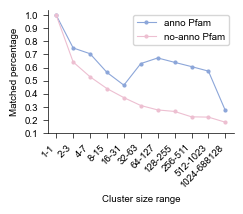

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

fig, ax = plt.subplots(figsize=(2.4, 1.6))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(df['bin_idx'], ["-".join([str(j) for j in bins[i]]) for i in df['bin_idx']], rotation=45, ha='right')

# plt.plot(df['bin_idx'], df['size_ratio'], markersize=4, marker='o')
plt.plot(df['bin_idx'], df['pro_pred_ratio_in_anno_pfam'], markersize=2, marker='o')
plt.plot(df['bin_idx'], df['pro_pred_ratio'], markersize=2, marker='o')
plt.yticks(np.linspace(0.1, 1.0, 10))

plt.ylabel("Matched percentage")
plt.xlabel("Cluster size range")
plt.legend(
    labels=[# 'total protein',
            'anno Pfam',
            'no-anno Pfam'],
    loc='upper right',
    bbox_to_anchor=(1,1)
)

fig.savefig(fig_file, bbox_inches="tight", transparent=True)